<a href="https://colab.research.google.com/github/Abhiraj36/Compression01/blob/main/Linear_Regression_Compression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MSE: 3277.58


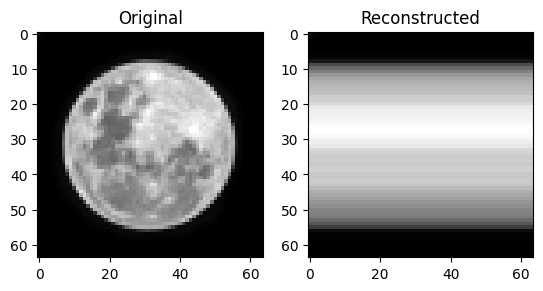

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.linear_model import LinearRegression

# 1️ Load grayscale image (for simplicity, we load a single image here)
def load_grayscale_image(path, size=(64, 64)):
    img = Image.open(path).convert('L')  # 'L' for grayscale
    img = img.resize(size)
    img_array = np.array(img).astype(np.float32)
    return img_array

# 2️ Train linear regression models row-wise
def train_rowwise_models(img_array):
    height, width = img_array.shape
    models = []
    for i in range(1, height):
        X = img_array[i-1].reshape(-1, 1)  # previous row as feature
        y = img_array[i]  # current row as target
        model = LinearRegression().fit(X, y)
        models.append((model.coef_[0], model.intercept_))
    return models

# 3️ Compress image: store first row + models
def compress_image(img_array):
    first_row = img_array[0]
    models = train_rowwise_models(img_array)
    return first_row, models

# 4️ Decompress image
def decompress_image(first_row, models):
    height = len(models) + 1
    width = len(first_row)
    reconstructed = np.zeros((height, width))
    reconstructed[0] = first_row
    for i, (coef, intercept) in enumerate(models):
        reconstructed[i+1] = reconstructed[i] * coef + intercept
    reconstructed = np.clip(reconstructed, 0, 255)
    return reconstructed.astype(np.uint8)

# 5️ Evaluation: visualize and compute MSE
def evaluate(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    print(f"MSE: {mse:.2f}")
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(original, cmap='gray')
    plt.subplot(1, 2, 2)
    plt.title("Reconstructed")
    plt.imshow(reconstructed, cmap='gray')
    plt.show()

# Example usage:
if __name__ == "__main__":
    img = load_grayscale_image("test_image.jpg", size=(64, 64))
    first_row, models = compress_image(img)
    reconstructed_img = decompress_image(first_row, models)
    evaluate(img, reconstructed_img)


MSE: 3277.58


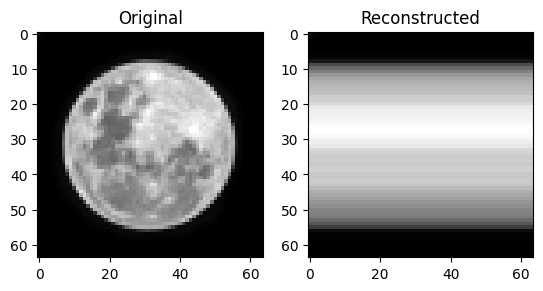

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.linear_model import LinearRegression

# Load grayscale image and normalize to [0,1]
def load_grayscale_image(path, size=(64, 64)):
    img = Image.open(path).convert('L').resize(size)
    img_array = np.array(img).astype(np.float32) / 255.0
    return img_array

def train_rowwise_models(img_array):
    height, width = img_array.shape
    models = []
    for i in range(1, height):
        X = img_array[i-1].reshape(-1, 1)
        y = img_array[i]
        model = LinearRegression().fit(X, y)
        models.append((model.coef_[0], model.intercept_))
    return models

def compress_image(img_array):
    first_row = img_array[0]
    models = train_rowwise_models(img_array)
    return first_row, models

def decompress_image(first_row, models):
    height = len(models) + 1
    width = len(first_row)
    reconstructed = np.zeros((height, width))
    reconstructed[0] = first_row
    for i, (coef, intercept) in enumerate(models):
        reconstructed[i+1] = reconstructed[i] * coef + intercept
    reconstructed = np.clip(reconstructed, 0.0, 1.0)
    return (reconstructed * 255).astype(np.uint8)

def evaluate(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    print(f"MSE: {mse:.2f}")
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(original, cmap='gray')
    plt.subplot(1, 2, 2)
    plt.title("Reconstructed")
    plt.imshow(reconstructed, cmap='gray')
    plt.show()

# Full workflow
if __name__ == "__main__":
    img = Image.open("test_image.jpg").convert('L').resize((64, 64))
    img_array = np.array(img).astype(np.float32)
    normalized_img = img_array / 255.0

    first_row, models = compress_image(normalized_img)
    reconstructed_img = decompress_image(first_row, models)

    evaluate(img_array, reconstructed_img)


MSE: 3277.58


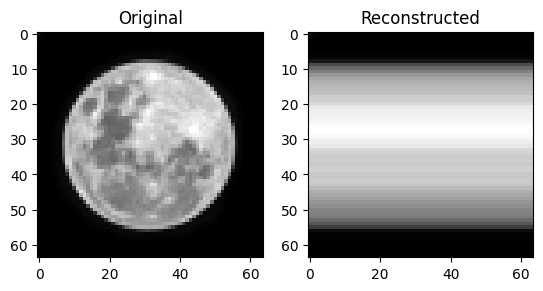

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.linear_model import LinearRegression

def load_grayscale_image(path, size=(64, 64)):
    img = Image.open(path).convert('L').resize(size)
    img_array = np.array(img).astype(np.float32)
    mean = np.mean(img_array)
    std = np.std(img_array)
    standardized_img = (img_array - mean) / std
    return standardized_img, mean, std

def train_rowwise_models(img_array):
    height, width = img_array.shape
    models = []
    for i in range(1, height):
        X = img_array[i-1].reshape(-1, 1)
        y = img_array[i]
        model = LinearRegression().fit(X, y)
        models.append((model.coef_[0], model.intercept_))
    return models

def compress_image(img_array):
    first_row = img_array[0]
    models = train_rowwise_models(img_array)
    return first_row, models

def decompress_image(first_row, models):
    height = len(models) + 1
    width = len(first_row)
    reconstructed = np.zeros((height, width))
    reconstructed[0] = first_row
    for i, (coef, intercept) in enumerate(models):
        reconstructed[i+1] = reconstructed[i] * coef + intercept
    return reconstructed

def evaluate(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    print(f"MSE: {mse:.2f}")
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(original, cmap='gray')
    plt.subplot(1, 2, 2)
    plt.title("Reconstructed")
    plt.imshow(reconstructed, cmap='gray')
    plt.show()

# Full workflow
if __name__ == "__main__":
    img = Image.open("test_image.jpg").convert('L').resize((64, 64))
    img_array = np.array(img).astype(np.float32)

    standardized_img, mean, std = load_grayscale_image("test_image.jpg", size=(64, 64))

    first_row, models = compress_image(standardized_img)
    reconstructed_standard = decompress_image(first_row, models)

    # De-standardize
    reconstructed_img = (reconstructed_standard * std) + mean
    reconstructed_img = np.clip(reconstructed_img, 0, 255).astype(np.uint8)

    evaluate(img_array, reconstructed_img)


Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Loaded 1000 images.
Building training data...
Training global model...
Trained model: coef=0.9064, intercept=0.0430
MSE: 97.10


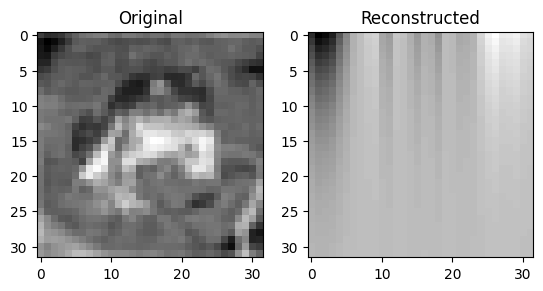

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from tensorflow.keras.datasets import cifar10
from PIL import Image

# Convert RGB image to grayscale
def rgb2gray(img):
    return np.dot(img[..., :3], [0.299, 0.587, 0.114])  # standard luminance conversion

# Load CIFAR-10 and preprocess
def load_cifar10_grayscale(num_samples=1000, target_size=(32, 32)):
    (x_train, _), (_, _) = cifar10.load_data()
    x_train = x_train[:num_samples]
    images = []
    for img in x_train:
        gray = rgb2gray(img)
        img_resized = Image.fromarray(gray.astype(np.uint8)).resize(target_size)
        img_array = np.array(img_resized).astype(np.float32) / 255.0
        images.append(img_array)
    return images

# Build dataset of (prev_row, current_row) pairs
def build_training_data(images):
    X_train = []
    y_train = []
    for img in images:
        height, width = img.shape
        for i in range(1, height):
            prev_row = img[i-1].reshape(-1, 1)
            curr_row = img[i]
            X_train.append(prev_row)
            y_train.append(curr_row)
    X_train = np.vstack(X_train)
    y_train = np.hstack(y_train)
    return X_train, y_train

# Train global linear regression
def train_global_model(X_train, y_train):
    model = LinearRegression().fit(X_train, y_train)
    print(f"Trained model: coef={model.coef_[0]:.4f}, intercept={model.intercept_:.4f}")
    return model

# Compression: just store first row
def compress_image(img_array):
    return img_array[0]

# Decompression: use model recursively
def decompress_image(first_row, model, height):
    width = len(first_row)
    reconstructed = np.zeros((height, width))
    reconstructed[0] = first_row
    coef = model.coef_[0]
    intercept = model.intercept_
    for i in range(1, height):
        reconstructed[i] = reconstructed[i-1] * coef + intercept
    reconstructed = np.clip(reconstructed, 0.0, 1.0)
    return (reconstructed * 255).astype(np.uint8)

# Evaluation
def evaluate(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    print(f"MSE: {mse:.2f}")
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(original, cmap='gray')
    plt.subplot(1, 2, 2)
    plt.title("Reconstructed")
    plt.imshow(reconstructed, cmap='gray')
    plt.show()

# Main workflow
if __name__ == "__main__":
    print("Loading CIFAR-10 dataset...")
    images = load_cifar10_grayscale(num_samples=1000, target_size=(32, 32))
    print(f"Loaded {len(images)} images.")

    print("Building training data...")
    X_train, y_train = build_training_data(images)

    print("Training global model...")
    model = train_global_model(X_train, y_train)

    # Test on one image
    test_img = images[0]
    original_img = (test_img * 255).astype(np.uint8)

    first_row = compress_image(test_img)
    reconstructed_img = decompress_image(first_row, model, height=32)

    evaluate(original_img, reconstructed_img)


Loading CIFAR-10 dataset...
Loaded 1000 images.
Building multivariate training data...
Training multivariate global model...
Trained model coefficients:
center: 0.8256, left: 0.0444, right: 0.0465, intercept: 0.0396
MSE: 101.11


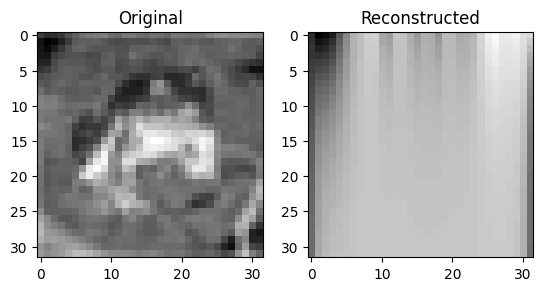

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from tensorflow.keras.datasets import cifar10
from PIL import Image

# Convert RGB image to grayscale
def rgb2gray(img):
    return np.dot(img[..., :3], [0.299, 0.587, 0.114])

# Load CIFAR-10 and preprocess
def load_cifar10_grayscale(num_samples=1000, target_size=(32, 32)):
    (x_train, _), (_, _) = cifar10.load_data()
    x_train = x_train[:num_samples]
    images = []
    for img in x_train:
        gray = rgb2gray(img)
        img_resized = Image.fromarray(gray.astype(np.uint8)).resize(target_size)
        img_array = np.array(img_resized).astype(np.float32) / 255.0
        images.append(img_array)
    return images

# Build multivariate training data: [x_i, x_i-1, x_i+1]
def build_training_data(images):
    X_train = []
    y_train = []
    for img in images:
        height, width = img.shape
        for i in range(1, height):
            prev_row = img[i-1]
            curr_row = img[i]
            for j in range(width):
                center = prev_row[j]
                left = prev_row[j-1] if j-1 >= 0 else 0.0  # pad with zero if out of bounds
                right = prev_row[j+1] if j+1 < width else 0.0
                X_train.append([center, left, right])
                y_train.append(curr_row[j])
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    return X_train, y_train

# Train multivariate linear regression model
def train_global_model(X_train, y_train):
    model = LinearRegression().fit(X_train, y_train)
    print("Trained model coefficients:")
    print(f"center: {model.coef_[0]:.4f}, left: {model.coef_[1]:.4f}, right: {model.coef_[2]:.4f}, intercept: {model.intercept_:.4f}")
    return model

# Compress: just store first row
def compress_image(img_array):
    return img_array[0]

# Decompress image using multivariate model
def decompress_image(first_row, model, height):
    width = len(first_row)
    reconstructed = np.zeros((height, width))
    reconstructed[0] = first_row

    for i in range(1, height):
        prev_row = reconstructed[i-1] / 255.0  # scale back to [0,1]
        new_row = np.zeros(width)
        for j in range(width):
            center = prev_row[j]
            left = prev_row[j-1] if j-1 >= 0 else 0.0
            right = prev_row[j+1] if j+1 < width else 0.0
            features = np.array([center, left, right]).reshape(1, -1)
            pred = model.predict(features)[0]
            new_row[j] = np.clip(pred, 0.0, 1.0)
        reconstructed[i] = new_row * 255  # scale back to [0,255]
    return reconstructed.astype(np.uint8)

# Evaluation
def evaluate(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    print(f"MSE: {mse:.2f}")
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(original, cmap='gray')
    plt.subplot(1, 2, 2)
    plt.title("Reconstructed")
    plt.imshow(reconstructed, cmap='gray')
    plt.show()

# Main workflow
if __name__ == "__main__":
    print("Loading CIFAR-10 dataset...")
    images = load_cifar10_grayscale(num_samples=1000, target_size=(32, 32))
    print(f"Loaded {len(images)} images.")

    print("Building multivariate training data...")
    X_train, y_train = build_training_data(images)

    print("Training multivariate global model...")
    model = train_global_model(X_train, y_train)

    # Test on one image
    test_img = images[0]
    original_img = (test_img * 255).astype(np.uint8)

    first_row = compress_image(original_img)
    reconstructed_img = decompress_image(first_row, model, height=32)

    evaluate(original_img, reconstructed_img)


Loading CIFAR-10 dataset...
Loaded 1000 images.
Building skip mode training data...
Training skip mode model...
Trained skip model: coef=0.7643, intercept=0.1090
MSE: 89.83


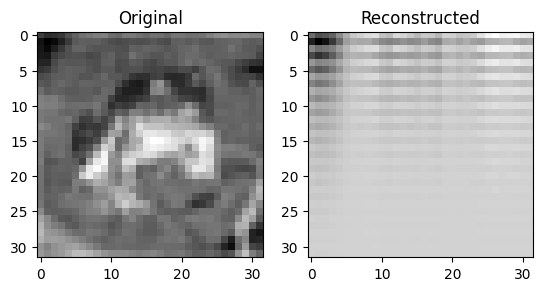

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from tensorflow.keras.datasets import cifar10
from PIL import Image

# Convert RGB image to grayscale
def rgb2gray(img):
    return np.dot(img[..., :3], [0.299, 0.587, 0.114])

# Load CIFAR-10 and preprocess
def load_cifar10_grayscale(num_samples=1000, target_size=(32, 32)):
    (x_train, _), (_, _) = cifar10.load_data()
    x_train = x_train[:num_samples]
    images = []
    for img in x_train:
        gray = rgb2gray(img)
        img_resized = Image.fromarray(gray.astype(np.uint8)).resize(target_size)
        img_array = np.array(img_resized).astype(np.float32) / 255.0
        images.append(img_array)
    return images

# Build training data using skip rows (i-2 predictor)
def build_training_data_skip(images, skip=2):
    X_train = []
    y_train = []
    for img in images:
        height, width = img.shape
        for i in range(skip, height):
            prev_row = img[i-skip]
            curr_row = img[i]
            for j in range(width):
                X_train.append([prev_row[j]])
                y_train.append(curr_row[j])
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    return X_train, y_train

# Train the linear model
def train_skip_model(X_train, y_train):
    model = LinearRegression().fit(X_train, y_train)
    print(f"Trained skip model: coef={model.coef_[0]:.4f}, intercept={model.intercept_:.4f}")
    return model

# Compression: store first two rows
def compress_image(img_array):
    return img_array[0], img_array[1]

# Decompression
def decompress_image(first_row, second_row, model, height):
    width = len(first_row)
    reconstructed = np.zeros((height, width))
    reconstructed[0] = first_row
    reconstructed[1] = second_row

    for i in range(2, height):
        prev_row = reconstructed[i-2] / 255.0  # scale back to [0,1]
        new_row = model.predict(prev_row.reshape(-1,1))
        new_row = np.clip(new_row, 0.0, 1.0)
        reconstructed[i] = new_row * 255  # scale back to [0,255]
    return reconstructed.astype(np.uint8)

# Evaluation
def evaluate(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    print(f"MSE: {mse:.2f}")
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(original, cmap='gray')
    plt.subplot(1, 2, 2)
    plt.title("Reconstructed")
    plt.imshow(reconstructed, cmap='gray')
    plt.show()

# Main workflow
if __name__ == "__main__":
    print("Loading CIFAR-10 dataset...")
    images = load_cifar10_grayscale(num_samples=1000, target_size=(32, 32))
    print(f"Loaded {len(images)} images.")

    print("Building skip mode training data...")
    X_train, y_train = build_training_data_skip(images, skip=2)

    print("Training skip mode model...")
    model = train_skip_model(X_train, y_train)

    # Test on one image
    test_img = images[0]
    original_img = (test_img * 255).astype(np.uint8)

    first_row, second_row = compress_image(original_img)
    reconstructed_img = decompress_image(first_row, second_row, model, height=32)

    evaluate(original_img, reconstructed_img)


Loading CIFAR-10 dataset...
Loaded 1000 images.
Building combo mode training data...
Training combo mode model...
Trained combo model: coef_1=1.2122, coef_2=-0.3342, intercept=0.0571
MSE: 92.13


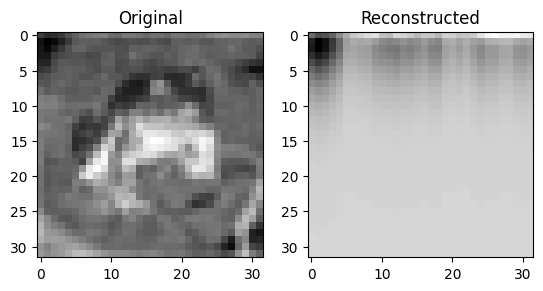

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from tensorflow.keras.datasets import cifar10
from PIL import Image

# Convert RGB image to grayscale
def rgb2gray(img):
    return np.dot(img[..., :3], [0.299, 0.587, 0.114])

# Load CIFAR-10 and preprocess
def load_cifar10_grayscale(num_samples=1000, target_size=(32, 32)):
    (x_train, _), (_, _) = cifar10.load_data()
    x_train = x_train[:num_samples]
    images = []
    for img in x_train:
        gray = rgb2gray(img)
        img_resized = Image.fromarray(gray.astype(np.uint8)).resize(target_size)
        img_array = np.array(img_resized).astype(np.float32) / 255.0
        images.append(img_array)
    return images

# Build training data for combo mode
def build_training_data_combo(images):
    X_train = []
    y_train = []
    for img in images:
        height, width = img.shape
        for i in range(2, height):  # start from row 2
            prev_row_1 = img[i-1]
            prev_row_2 = img[i-2]
            curr_row = img[i]
            for j in range(width):
                X_train.append([prev_row_1[j], prev_row_2[j]])
                y_train.append(curr_row[j])
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    return X_train, y_train

# Train the linear model
def train_combo_model(X_train, y_train):
    model = LinearRegression().fit(X_train, y_train)
    print(f"Trained combo model: coef_1={model.coef_[0]:.4f}, coef_2={model.coef_[1]:.4f}, intercept={model.intercept_:.4f}")
    return model

# Compression: store first two rows
def compress_image(img_array):
    return img_array[0], img_array[1]

# Decompression
def decompress_image(first_row, second_row, model, height):
    width = len(first_row)
    reconstructed = np.zeros((height, width))
    reconstructed[0] = first_row
    reconstructed[1] = second_row

    for i in range(2, height):
        prev_row_1 = reconstructed[i-1] / 255.0
        prev_row_2 = reconstructed[i-2] / 255.0
        X_row = np.vstack((prev_row_1, prev_row_2)).T  # shape (width, 2)
        new_row = model.predict(X_row)
        new_row = np.clip(new_row, 0.0, 1.0)
        reconstructed[i] = new_row * 255
    return reconstructed.astype(np.uint8)

# Evaluation
def evaluate(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    print(f"MSE: {mse:.2f}")
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(original, cmap='gray')
    plt.subplot(1, 2, 2)
    plt.title("Reconstructed")
    plt.imshow(reconstructed, cmap='gray')
    plt.show()

# Main workflow
if __name__ == "__main__":
    print("Loading CIFAR-10 dataset...")
    images = load_cifar10_grayscale(num_samples=1000, target_size=(32, 32))
    print(f"Loaded {len(images)} images.")

    print("Building combo mode training data...")
    X_train, y_train = build_training_data_combo(images)

    print("Training combo mode model...")
    model = train_combo_model(X_train, y_train)

    # Test on one image
    test_img = images[0]
    original_img = (test_img * 255).astype(np.uint8)

    first_row, second_row = compress_image(original_img)
    reconstructed_img = decompress_image(first_row, second_row, model, height=32)

    evaluate(original_img, reconstructed_img)


Loading CIFAR-10 dataset...
Loaded 1000 images.
Building multi-skip training data...
Training multi-skip model...
Trained multiskip model: coef_1=1.2932, coef_2=-0.6335, coef_3=0.2438, intercept=0.0443
MSE: 86.79


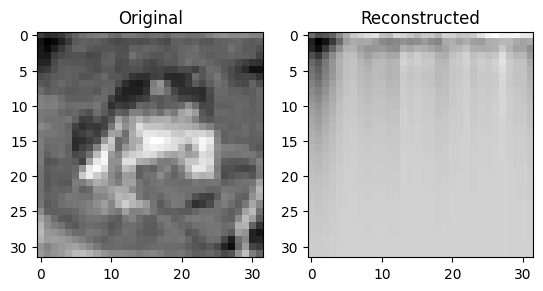

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from tensorflow.keras.datasets import cifar10
from PIL import Image

# Convert RGB image to grayscale
def rgb2gray(img):
    return np.dot(img[..., :3], [0.299, 0.587, 0.114])

# Load CIFAR-10 and preprocess
def load_cifar10_grayscale(num_samples=1000, target_size=(32, 32)):
    (x_train, _), (_, _) = cifar10.load_data()
    x_train = x_train[:num_samples]
    images = []
    for img in x_train:
        gray = rgb2gray(img)
        img_resized = Image.fromarray(gray.astype(np.uint8)).resize(target_size)
        img_array = np.array(img_resized).astype(np.float32) / 255.0
        images.append(img_array)
    return images

# Build training data for multi-skip mode (i-1, i-2, i-3)
def build_training_data_multiskip(images):
    X_train = []
    y_train = []
    for img in images:
        height, width = img.shape
        for i in range(3, height):
            prev_row_1 = img[i-1]
            prev_row_2 = img[i-2]
            prev_row_3 = img[i-3]
            curr_row = img[i]
            for j in range(width):
                X_train.append([prev_row_1[j], prev_row_2[j], prev_row_3[j]])
                y_train.append(curr_row[j])
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    return X_train, y_train

# Train the linear model
def train_multiskip_model(X_train, y_train):
    model = LinearRegression().fit(X_train, y_train)
    print(f"Trained multiskip model: coef_1={model.coef_[0]:.4f}, coef_2={model.coef_[1]:.4f}, coef_3={model.coef_[2]:.4f}, intercept={model.intercept_:.4f}")
    return model

# Compression: store first three rows
def compress_image(img_array):
    return img_array[0], img_array[1], img_array[2]

# Decompression
def decompress_image(first_row, second_row, third_row, model, height):
    width = len(first_row)
    reconstructed = np.zeros((height, width))
    reconstructed[0] = first_row
    reconstructed[1] = second_row
    reconstructed[2] = third_row

    for i in range(3, height):
        prev_row_1 = reconstructed[i-1] / 255.0
        prev_row_2 = reconstructed[i-2] / 255.0
        prev_row_3 = reconstructed[i-3] / 255.0
        X_row = np.vstack((prev_row_1, prev_row_2, prev_row_3)).T
        new_row = model.predict(X_row)
        new_row = np.clip(new_row, 0.0, 1.0)
        reconstructed[i] = new_row * 255
    return reconstructed.astype(np.uint8)

# Evaluation
def evaluate(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    print(f"MSE: {mse:.2f}")
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(original, cmap='gray')
    plt.subplot(1, 2, 2)
    plt.title("Reconstructed")
    plt.imshow(reconstructed, cmap='gray')
    plt.show()

# Main workflow
if __name__ == "__main__":
    print("Loading CIFAR-10 dataset...")
    images = load_cifar10_grayscale(num_samples=1000, target_size=(32, 32))
    print(f"Loaded {len(images)} images.")

    print("Building multi-skip training data...")
    X_train, y_train = build_training_data_multiskip(images)

    print("Training multi-skip model...")
    model = train_multiskip_model(X_train, y_train)

    # Test on one image
    test_img = images[0]
    original_img = (test_img * 255).astype(np.uint8)

    first_row, second_row, third_row = compress_image(original_img)
    reconstructed_img = decompress_image(first_row, second_row, third_row, model, height=32)

    evaluate(original_img, reconstructed_img)


Loading CIFAR-10 dataset...
Loaded 1000 images.
Building patch mode training data...
Training patch mode model...
Trained patch model: top=0.0289, left=0.6829, top-left=-0.1004, top-right=0.3924, intercept=-0.0027
MSE: 96.52


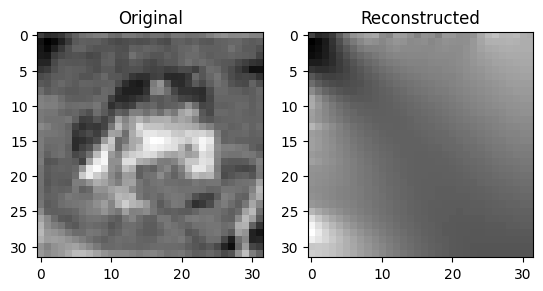

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from tensorflow.keras.datasets import cifar10
from PIL import Image

# Convert RGB image to grayscale
def rgb2gray(img):
    return np.dot(img[..., :3], [0.299, 0.587, 0.114])

# Load CIFAR-10 and preprocess
def load_cifar10_grayscale(num_samples=1000, target_size=(32, 32)):
    (x_train, _), (_, _) = cifar10.load_data()
    x_train = x_train[:num_samples]
    images = []
    for img in x_train:
        gray = rgb2gray(img)
        img_resized = Image.fromarray(gray.astype(np.uint8)).resize(target_size)
        img_array = np.array(img_resized).astype(np.float32) / 255.0
        images.append(img_array)
    return images

# Build training data for patch mode
def build_training_data_patch(images):
    X_train = []
    y_train = []
    for img in images:
        height, width = img.shape
        for i in range(1, height):
            for j in range(1, width-1):
                top = img[i-1, j]
                left = img[i, j-1]
                top_left = img[i-1, j-1]
                top_right = img[i-1, j+1]
                current = img[i, j]
                X_train.append([top, left, top_left, top_right])
                y_train.append(current)
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    return X_train, y_train

# Train the linear model
def train_patch_model(X_train, y_train):
    model = LinearRegression().fit(X_train, y_train)
    print(f"Trained patch model: top={model.coef_[0]:.4f}, left={model.coef_[1]:.4f}, top-left={model.coef_[2]:.4f}, top-right={model.coef_[3]:.4f}, intercept={model.intercept_:.4f}")
    return model

# Compression: store first row and first column
def compress_image(img_array):
    return img_array[0], img_array[:, 0]

# Decompression
def decompress_image(first_row, first_column, model, height, width):
    reconstructed = np.zeros((height, width))
    reconstructed[0] = first_row
    reconstructed[:, 0] = first_column

    for i in range(1, height):
        for j in range(1, width-1):
            top = reconstructed[i-1, j] / 255.0
            left = reconstructed[i, j-1] / 255.0
            top_left = reconstructed[i-1, j-1] / 255.0
            top_right = reconstructed[i-1, j+1] / 255.0
            X_pixel = np.array([[top, left, top_left, top_right]])
            pred = model.predict(X_pixel)[0]
            pred = np.clip(pred, 0.0, 1.0)
            reconstructed[i, j] = pred * 255

        # Handle last column separately (skip prediction for j=width-1)
        reconstructed[i, -1] = reconstructed[i, -2]

    return reconstructed.astype(np.uint8)

# Evaluation
def evaluate(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    print(f"MSE: {mse:.2f}")
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(original, cmap='gray')
    plt.subplot(1, 2, 2)
    plt.title("Reconstructed")
    plt.imshow(reconstructed, cmap='gray')
    plt.show()

# Main workflow
if __name__ == "__main__":
    print("Loading CIFAR-10 dataset...")
    images = load_cifar10_grayscale(num_samples=1000, target_size=(32, 32))
    print(f"Loaded {len(images)} images.")

    print("Building patch mode training data...")
    X_train, y_train = build_training_data_patch(images)

    print("Training patch mode model...")
    model = train_patch_model(X_train, y_train)

    # Test on one image
    test_img = images[0]
    original_img = (test_img * 255).astype(np.uint8)

    first_row, first_column = compress_image(original_img)
    reconstructed_img = decompress_image(first_row, first_column, model, height=32, width=32)

    evaluate(original_img, reconstructed_img)


Loading CIFAR-10 dataset...
Loaded 1000 images.
Building final boss training data...
Training final boss model...
Trained final boss model:
row_m1=0.0911, row_m2=-0.1665, row_m3=0.0243,
left=0.6027, top_left=0.0132, top_right=0.4306, intercept=0.0014
MSE: 81.04


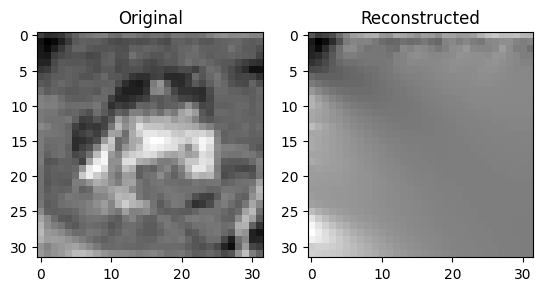

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from tensorflow.keras.datasets import cifar10
from PIL import Image

# Convert RGB image to grayscale
def rgb2gray(img):
    return np.dot(img[..., :3], [0.299, 0.587, 0.114])

# Load CIFAR-10 and preprocess
def load_cifar10_grayscale(num_samples=1000, target_size=(32, 32)):
    (x_train, _), (_, _) = cifar10.load_data()
    x_train = x_train[:num_samples]
    images = []
    for img in x_train:
        gray = rgb2gray(img)
        img_resized = Image.fromarray(gray.astype(np.uint8)).resize(target_size)
        img_array = np.array(img_resized).astype(np.float32) / 255.0
        images.append(img_array)
    return images

# Build training data for Final Boss mode
def build_training_data_final_boss(images):
    X_train = []
    y_train = []
    for img in images:
        height, width = img.shape
        for i in range(3, height):
            for j in range(1, width-1):
                row_m1 = img[i-1, j]
                row_m2 = img[i-2, j]
                row_m3 = img[i-3, j]
                left = img[i, j-1]
                top_left = img[i-1, j-1]
                top_right = img[i-1, j+1]
                current = img[i, j]
                X_train.append([row_m1, row_m2, row_m3, left, top_left, top_right])
                y_train.append(current)
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    return X_train, y_train

# Train model
def train_final_boss_model(X_train, y_train):
    model = LinearRegression().fit(X_train, y_train)
    print(f"Trained final boss model:")
    print(f"row_m1={model.coef_[0]:.4f}, row_m2={model.coef_[1]:.4f}, row_m3={model.coef_[2]:.4f},")
    print(f"left={model.coef_[3]:.4f}, top_left={model.coef_[4]:.4f}, top_right={model.coef_[5]:.4f}, intercept={model.intercept_:.4f}")
    return model

# Compress: store first 3 rows + first column
def compress_image(img_array):
    return img_array[0:3], img_array[:, 0]

# Decompress
def decompress_image(first_rows, first_column, model, height, width):
    reconstructed = np.zeros((height, width))
    reconstructed[0:3] = first_rows
    reconstructed[:, 0] = first_column

    for i in range(3, height):
        for j in range(1, width-1):
            row_m1 = reconstructed[i-1, j] / 255.0
            row_m2 = reconstructed[i-2, j] / 255.0
            row_m3 = reconstructed[i-3, j] / 255.0
            left = reconstructed[i, j-1] / 255.0
            top_left = reconstructed[i-1, j-1] / 255.0
            top_right = reconstructed[i-1, j+1] / 255.0
            X_pixel = np.array([[row_m1, row_m2, row_m3, left, top_left, top_right]])
            pred = model.predict(X_pixel)[0]
            pred = np.clip(pred, 0.0, 1.0)
            reconstructed[i, j] = pred * 255
        reconstructed[i, -1] = reconstructed[i, -2]

    return reconstructed.astype(np.uint8)

# Evaluate
def evaluate(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    print(f"MSE: {mse:.2f}")
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(original, cmap='gray')
    plt.subplot(1, 2, 2)
    plt.title("Reconstructed")
    plt.imshow(reconstructed, cmap='gray')
    plt.show()

# Main
if __name__ == "__main__":
    print("Loading CIFAR-10 dataset...")
    images = load_cifar10_grayscale(num_samples=1000, target_size=(32, 32))
    print(f"Loaded {len(images)} images.")

    print("Building final boss training data...")
    X_train, y_train = build_training_data_final_boss(images)

    print("Training final boss model...")
    model = train_final_boss_model(X_train, y_train)

    # Test on one image
    test_img = images[0]
    original_img = (test_img * 255).astype(np.uint8)

    first_rows, first_column = compress_image(original_img)
    reconstructed_img = decompress_image(first_rows, first_column, model, height=32, width=32)

    evaluate(original_img, reconstructed_img)
